In [1]:
pip install spreg

<Axes: >

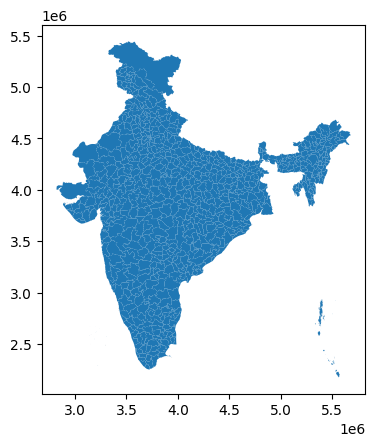

In [2]:
import geopandas as gpd
gdf = gpd.read_file("DISTRICT_BOUNDARY.shp")
gdf.plot()

In [3]:
print(gdf.columns)

Index(['OBJECTID', 'STATE_LGD', 'DISTRICT', 'STATE_UT', 'Shape_Leng',
       'Shape_Area', 'Dist_LGD', 'REMARKS', 'geometry'],
      dtype='object')


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("01_District_wise_crimes_committed_IPC_2001_2012.csv")
print(df)

            STATE/UT       DISTRICT  YEAR  MURDER  ATTEMPT TO MURDER  \
0     ANDHRA PRADESH       ADILABAD  2001     101                 60   
1     ANDHRA PRADESH      ANANTAPUR  2001     151                125   
2     ANDHRA PRADESH       CHITTOOR  2001     101                 57   
3     ANDHRA PRADESH       CUDDAPAH  2001      80                 53   
4     ANDHRA PRADESH  EAST GODAVARI  2001      82                 67   
...              ...            ...   ...     ...                ...   
9012     LAKSHADWEEP    LAKSHADWEEP  2012       0                  0   
9013     LAKSHADWEEP          TOTAL  2012       0                  0   
9014      PUDUCHERRY       KARAIKAL  2012       5                  6   
9015      PUDUCHERRY     PUDUCHERRY  2012      24                 21   
9016      PUDUCHERRY          TOTAL  2012      29                 27   

      CULPABLE HOMICIDE NOT AMOUNTING TO MURDER  RAPE  CUSTODIAL RAPE  \
0                                            17    50         

In [27]:
literacy_df = pd.read_csv("Literacy Data 2011.csv")

# Clean the 'State' column by stripping whitespace
literacy_df['State'] = literacy_df['State'].str.strip()

# Filter for Gujarat state
print("Unique states in literacy_df after stripping whitespace:")
print(literacy_df['State'].unique())
gujarat_literacy = literacy_df[literacy_df['State'] == 'Gujarat'].copy()

# Display requested columns
print("\nLiteracy data for Gujarat:")
display(gujarat_literacy[['State', 'District', 'Literacy']])

Unique states in literacy_df after stripping whitespace:
['Maharashtra' 'West Bengal' 'Karnataka' 'Gujarat' 'Rajasthan'
 'Uttar Pradesh' 'Bihar' 'Andhra Pradesh' 'Tamil Nadu' 'Kerala'
 'Chhattisgarh' 'Delhi' 'Orissa' 'Punjab' 'Madhya Pradesh' 'Jharkhand'
 'Assam' 'Uttarakhand' 'Haryana' 'Tripura' 'Jammu and Kashmir'
 'Himachal Pradesh' 'Chandigarh' 'Puducherry' 'Meghalaya' 'Goa' 'Manipur'
 'Mizoram' 'Nagaland' 'Dadra and Nagar Haveli' 'Sikkim'
 'Andaman And Nicobar Islands' 'Daman and Diu' 'Arunachal Pradesh'
 'Lakshadweep']

Literacy data for Gujarat:


,State,District,Literacy
7,Gujarat,Ahmadabad,85.31
11,Gujarat,Surat,85.53
47,Gujarat,Vadodara,78.92
66,Gujarat,Rajkot,80.96
110,Gujarat,Banaskantha,65.32
132,Gujarat,Bhavnagar,75.52
141,Gujarat,Junagadh,75.80
182,Gujarat,Sabarkantha,75.79
186,Gujarat,PanchMahal,70.99
195,Gujarat,Kheda,82.65


In [5]:
print(df.columns)

Index(['STATE/UT', 'DISTRICT', 'YEAR', 'MURDER', 'ATTEMPT TO MURDER',
       'CULPABLE HOMICIDE NOT AMOUNTING TO MURDER', 'RAPE', 'CUSTODIAL RAPE',
       'OTHER RAPE', 'KIDNAPPING & ABDUCTION',
       'KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS',
       'KIDNAPPING AND ABDUCTION OF OTHERS', 'DACOITY',
       'PREPARATION AND ASSEMBLY FOR DACOITY', 'ROBBERY', 'BURGLARY', 'THEFT',
       'AUTO THEFT', 'OTHER THEFT', 'RIOTS', 'CRIMINAL BREACH OF TRUST',
       'CHEATING', 'COUNTERFIETING', 'ARSON', 'HURT/GREVIOUS HURT',
       'DOWRY DEATHS', 'ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY',
       'INSULT TO MODESTY OF WOMEN', 'CRUELTY BY HUSBAND OR HIS RELATIVES',
       'IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES',
       'CAUSING DEATH BY NEGLIGENCE', 'OTHER IPC CRIMES', 'TOTAL IPC CRIMES'],
      dtype='object')


In [6]:
gdf = gpd.read_file("DISTRICT_BOUNDARY.shp")

#We'll rename 'STATE/UT' to avoid conflict and prefix other crime data columns.
crime_df_clean = df.copy()
crime_df_clean = crime_df_clean.rename(columns={'STATE/UT': 'CRIME_STATE_UT'})

#Add 'CRIME_' prefix to all other columns in crime_df_clean except 'DISTRICT'
columns_to_prefix = [col for col in crime_df_clean.columns if col not in ['DISTRICT', 'CRIME_STATE_UT']]
crime_df_clean.columns = [f'CRIME_{col}' if col in columns_to_prefix else col for col in crime_df_clean.columns]

#Perform the merge with the cleaned dataframes
gdf = gdf.merge(crime_df_clean, on='DISTRICT', how='inner')

print("Shape of merged GeoDataFrame:", gdf.shape)
print("Columns of merged GeoDataFrame:", gdf.columns.tolist())
display(gdf)

Shape of merged GeoDataFrame: (4934, 41)
Columns of merged GeoDataFrame: ['OBJECTID', 'STATE_LGD', 'DISTRICT', 'STATE_UT', 'Shape_Leng', 'Shape_Area', 'Dist_LGD', 'REMARKS', 'geometry', 'CRIME_STATE_UT', 'CRIME_YEAR', 'CRIME_MURDER', 'CRIME_ATTEMPT TO MURDER', 'CRIME_CULPABLE HOMICIDE NOT AMOUNTING TO MURDER', 'CRIME_RAPE', 'CRIME_CUSTODIAL RAPE', 'CRIME_OTHER RAPE', 'CRIME_KIDNAPPING & ABDUCTION', 'CRIME_KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS', 'CRIME_KIDNAPPING AND ABDUCTION OF OTHERS', 'CRIME_DACOITY', 'CRIME_PREPARATION AND ASSEMBLY FOR DACOITY', 'CRIME_ROBBERY', 'CRIME_BURGLARY', 'CRIME_THEFT', 'CRIME_AUTO THEFT', 'CRIME_OTHER THEFT', 'CRIME_RIOTS', 'CRIME_CRIMINAL BREACH OF TRUST', 'CRIME_CHEATING', 'CRIME_COUNTERFIETING', 'CRIME_ARSON', 'CRIME_HURT/GREVIOUS HURT', 'CRIME_DOWRY DEATHS', 'CRIME_ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY', 'CRIME_INSULT TO MODESTY OF WOMEN', 'CRIME_CRUELTY BY HUSBAND OR HIS RELATIVES', 'CRIME_IMPORTATION OF GIRLS FROM FOREIGN COUNTRIE

,OBJECTID,STATE_LGD,DISTRICT,STATE_UT,Shape_Leng,Shape_Area,Dist_LGD,REMARKS,geometry,CRIME_STATE_UT,...,CRIME_ARSON,CRIME_HURT/GREVIOUS HURT,CRIME_DOWRY DEATHS,CRIME_ASSAULT ON WOMEN WITH INTENT TO OUTRAGE HER MODESTY,CRIME_INSULT TO MODESTY OF WOMEN,CRIME_CRUELTY BY HUSBAND OR HIS RELATIVES,CRIME_IMPORTATION OF GIRLS FROM FOREIGN COUNTRIES,CRIME_CAUSING DEATH BY NEGLIGENCE,CRIME_OTHER IPC CRIMES,CRIME_TOTAL IPC CRIMES
0,6,28,CHITTOOR,ANDHRA PRADESH,1.122830e+06,6.662536e+09,554,None,"MULTIPOLYGON Z (((3969008.246 2843628.146 0, 3...",ANDHRA PRADESH,...,38,2088,14,112,83,186,0,404,1262,5818
1,6,28,CHITTOOR,ANDHRA PRADESH,1.122830e+06,6.662536e+09,554,None,"MULTIPOLYGON Z (((3969008.246 2843628.146 0, 3...",ANDHRA PRADESH,...,43,999,16,126,40,188,0,476,2788,6306
2,6,28,CHITTOOR,ANDHRA PRADESH,1.122830e+06,6.662536e+09,554,None,"MULTIPOLYGON Z (((3969008.246 2843628.146 0, 3...",ANDHRA PRADESH,...,27,1049,23,121,173,60,0,522,2678,6624
3,6,28,CHITTOOR,ANDHRA PRADESH,1.122830e+06,6.662536e+09,554,None,"MULTIPOLYGON Z (((3969008.246 2843628.146 0, 3...",ANDHRA PRADESH,...,30,1065,22,116,197,234,0,2058,1188,6960
4,6,28,CHITTOOR,ANDHRA PRADESH,1.122830e+06,6.662536e+09,554,None,"MULTIPOLYGON Z (((3969008.246 2843628.146 0, 3...",ANDHRA PRADESH,...,30,891,9,91,223,202,0,541,2573,6746
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4929,1428,12,LOHIT,ARUNACHAL PRADESH,3.862899e+05,2.961618e+09,234,None,"POLYGON Z ((5572653.242 4567014.078 0, 5572713...",ARUNACHAL PRADESH,...,0,19,0,1,0,0,0,10,50,159
4930,1428,12,LOHIT,ARUNACHAL PRADESH,3.862899e+05,2.961618e+09,234,None,"POLYGON Z ((5572653.242 4567014.078 0, 5572713...",ARUNACHAL PRADESH,...,1,29,0,5,0,0,0,8,41,170
4931,1428,12,LOHIT,ARUNACHAL PRADESH,3.862899e+05,2.961618e+09,234,None,"POLYGON Z ((5572653.242 4567014.078 0, 5572713...",ARUNACHAL PRADESH,...,7,34,0,7,0,0,0,12,34,176
4932,1428,12,LOHIT,ARUNACHAL PRADESH,3.862899e+05,2.961618e+09,234,None,"POLYGON Z ((5572653.242 4567014.078 0, 5572713...",ARUNACHAL PRADESH,...,2,16,0,2,0,0,0,15,32,158


In [7]:
#Filter the GeoDataFrame for 'Gujarat'
gujarat_gdf = gdf[gdf['CRIME_STATE_UT'] == 'GUJARAT'].copy()
print(gujarat_gdf)

      OBJECTID  STATE_LGD DISTRICT STATE_UT     Shape_Leng    Shape_Area  \
1120       183         24   AMRELI  GUJARAT  715627.570977  7.103591e+09   
1121       183         24   AMRELI  GUJARAT  715627.570977  7.103591e+09   
1122       183         24   AMRELI  GUJARAT  715627.570977  7.103591e+09   
1123       183         24   AMRELI  GUJARAT  715627.570977  7.103591e+09   
1124       183         24   AMRELI  GUJARAT  715627.570977  7.103591e+09   
...        ...        ...      ...      ...            ...           ...   
1288       215         24   VALSAD  GUJARAT  503925.528415  2.846763e+09   
1289       215         24   VALSAD  GUJARAT  503925.528415  2.846763e+09   
1290       215         24   VALSAD  GUJARAT  503925.528415  2.846763e+09   
1291       215         24   VALSAD  GUJARAT  503925.528415  2.846763e+09   
1292       215         24   VALSAD  GUJARAT  503925.528415  2.846763e+09   

     Dist_LGD REMARKS                                           geometry  \
1120      4

In [8]:
#Since we don't have actual district-wise and year-wise population data,
#We will create a hypothetical population for each district for each year.

#Define a hypothetical base population per district (e.g., 1.5 million)
hypothetical_base_district_population = 1_500_000
#Define a hypothetical population increase per year to show some variation
population_increase_per_year = 50_000

#Calculate hypothetical population for each district per year
gujarat_gdf['CRIME_POPULATION'] = hypothetical_base_district_population + \
                                       (gujarat_gdf['CRIME_YEAR'] - gujarat_gdf['CRIME_YEAR'].min()) * \
                                       population_increase_per_year

#Calculate the crime rate per 100,000 people for each district per year
gujarat_gdf['CRIME_RATE_PER_100K'] = (gujarat_gdf['CRIME_TOTAL IPC CRIMES'] / gujarat_gdf['CRIME_POPULATION']) * 100000

print("Updated gujarat_gdf with district-wise and year-wise hypothetical population and crime rate:")
display(gujarat_gdf[['DISTRICT', 'CRIME_YEAR', 'CRIME_TOTAL IPC CRIMES', 'CRIME_POPULATION', 'CRIME_RATE_PER_100K']].head())

Updated gujarat_gdf with district-wise and year-wise hypothetical population and crime rate:


,DISTRICT,CRIME_YEAR,CRIME_TOTAL IPC CRIMES,CRIME_POPULATION,CRIME_RATE_PER_100K
1120,AMRELI,2001,2191,1500000,146.066667
1121,AMRELI,2002,1851,1550000,119.419355
1122,AMRELI,2003,1940,1600000,121.250000
1123,AMRELI,2004,2240,1650000,135.757576
1124,AMRELI,2005,3578,1700000,210.470588


In [9]:
#Display the updated gujarat_gdf with the new crime rate column
print("Updated 'CRIME_RATE_PER_100K' column in gujarat_gdf with district-wise rates:")
display(gujarat_gdf[['DISTRICT', 'CRIME_YEAR', 'CRIME_TOTAL IPC CRIMES', 'CRIME_POPULATION', 'CRIME_RATE_PER_100K']].head())

Updated 'CRIME_RATE_PER_100K' column in gujarat_gdf with district-wise rates:


,DISTRICT,CRIME_YEAR,CRIME_TOTAL IPC CRIMES,CRIME_POPULATION,CRIME_RATE_PER_100K
1120,AMRELI,2001,2191,1500000,146.066667
1121,AMRELI,2002,1851,1550000,119.419355
1122,AMRELI,2003,1940,1600000,121.250000
1123,AMRELI,2004,2240,1650000,135.757576
1124,AMRELI,2005,3578,1700000,210.470588


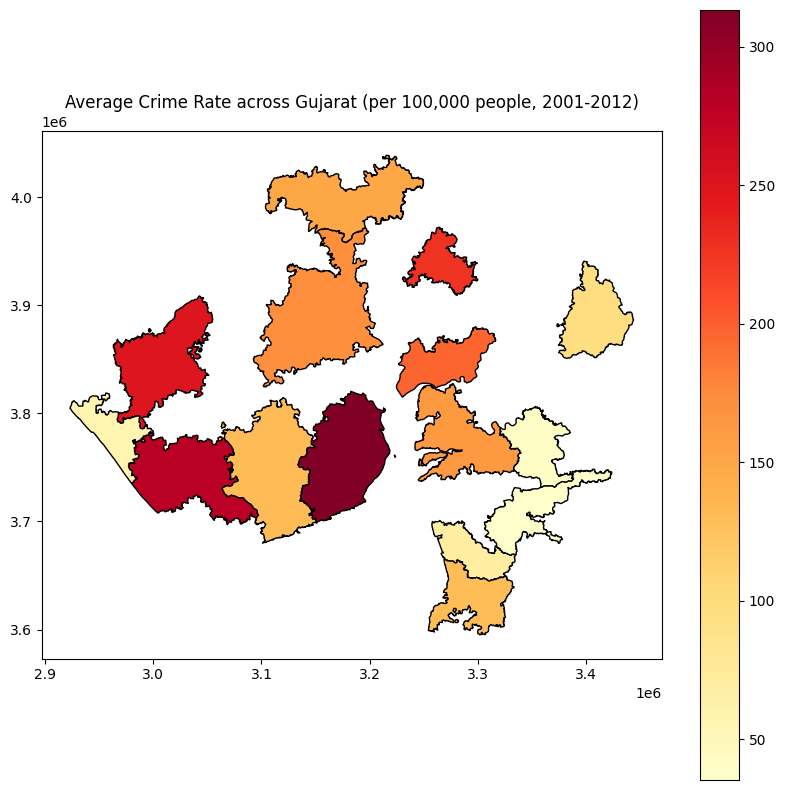

In [10]:
import matplotlib.pyplot as plt
from geopandas import GeoDataFrame

#Calculate the average crime rate per district across all years
#Since there are multiple years per district, we'll take the mean of the CRIME_RATE_PER_100K for each district
average_district_crime_rate = gujarat_gdf.groupby('DISTRICT').agg(
    Average_CRIME_RATE_PER_100K=('CRIME_RATE_PER_100K', 'mean'),
    geometry=('geometry', 'first') # Keep one geometry for each district
).reset_index()

#Convert to GeoDataFrame for plotting
average_district_crime_rate = GeoDataFrame(average_district_crime_rate, geometry='geometry')

#Plot the average crime rate per district
fig, ax = plt.subplots(1, 1, figsize=(10, 10))
average_district_crime_rate.plot(column='Average_CRIME_RATE_PER_100K',
                                 legend=True,
                                 cmap='YlOrRd',
                                 edgecolor='black',
                                 ax=ax)
plt.title('Average Crime Rate across Gujarat (per 100,000 people, 2001-2012)')
plt.show()

In [11]:
from libpysal.weights import Queen
weight = Queen.from_dataframe(gujarat_gdf, use_index=False)

/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 6 disconnected components.
  W.__init__(self, neighbors, ids=ids, **kw)


In [12]:
from esda.moran import Moran
y = gujarat_gdf['CRIME_RATE_PER_100K']
moran = Moran(y, weight)
print("Moran's I:", moran.I)
print("p-value:", moran.p_sim)

Moran's I: 0.26874572392997725
p-value: 0.001


The Moran’s I value of 0.268 with a p-value of 0.001 indicates the presence of moderate and statistically significant spatial clustering in crime rates across districts. This means that districts with similar crime rates tend to be located near each other rather than being randomly distributed. The significant p-value confirms that this pattern is unlikely to be due to chance, suggesting meaningful spatial dependence in crime patterns.

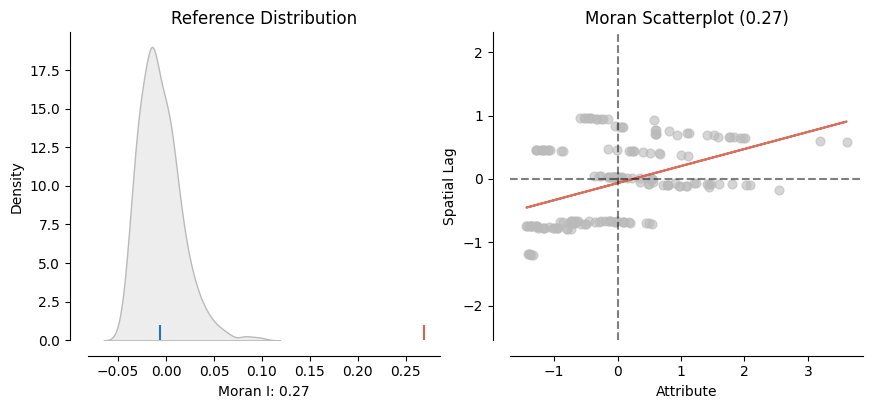

In [13]:
from splot.esda import plot_moran
plot_moran(moran)
plt.show()

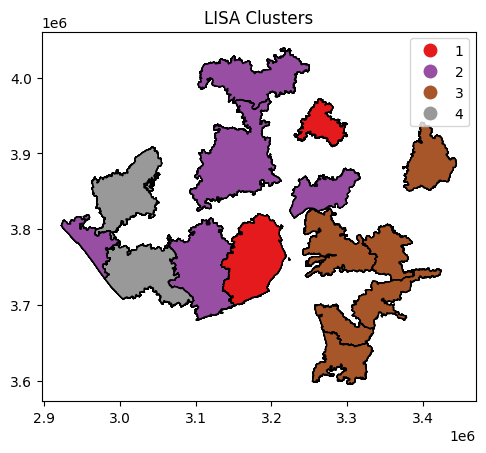

In [14]:
from esda.moran import Moran_Local
lisa = Moran_Local(y, weight)
gujarat_gdf['lisa_cluster'] = lisa.q
gujarat_gdf.plot(column='lisa_cluster', categorical=True, cmap='Set1', edgecolor='black', legend=True)
plt.title('LISA Clusters')
plt.show()

In [15]:
# Identify hotspots from LISA results
# lisa.q values typically map to:
# 1: High-High (hotspot)
# 2: Low-Low (coldspot)
# 3: High-Low (outlier where high values are surrounded by low values)
# 4: Low-High (outlier where low values are surrounded by high values)

hotspots_gdf = gujarat_gdf[gujarat_gdf['lisa_cluster'] == 1]

#Get unique district names from the hotspots
hotspot_districts = hotspots_gdf['DISTRICT'].unique()

print("Hotspot Districts:")
for district in hotspot_districts:
    print(f"- {district}")

Hotspot Districts:
- AMRELI
- ANAND
- BHAVNAGAR
- GANDHINAGAR
- PATAN
- SURENDRANAGAR


The identified hotspot districts are AMRELI, ANAND, BHAVNAGAR, GANDHINAGAR, PATAN, and SURENDRANAGAR. These districts exhibit 'High-High' clustering according to the LISA analysis, meaning they have high crime rates and are surrounded by other districts with high crime rates.

### OLS Regression for Each District in Gujarat (using CRIME_YEAR as predictor)

In [16]:
from spreg import OLS

#Group the GeoDataFrame by district
districts = gujarat_gdf['DISTRICT'].unique()

for district_name in districts:
    print(f"\n--- OLS for District: {district_name} ---")
    district_data = gujarat_gdf[gujarat_gdf['DISTRICT'] == district_name].copy()

    if len(district_data) > 1: #Need at least 2 data points for regression
        y_district = district_data['CRIME_RATE_PER_100K'].values.reshape((-1, 1))
        x_district = district_data[['CRIME_YEAR']].values

        #Run OLS for the district
        ols_district = OLS(y_district, x_district, name_y='CRIME_RATE_PER_100K', name_x=['CRIME_YEAR'], nonspat_diag=True)
        print(ols_district.summary)
    else:
        print(f"Not enough data to run OLS for {district_name} (only {len(district_data)} data point(s)).")


--- OLS for District: AMRELI ---
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :CRIME_RATE_PER_100K                Number of Observations:          12
Mean dependent var  :    131.3526                Number of Variables   :           2
S.D. dependent var  :     27.6596                Degrees of Freedom    :          10
R-squared           :      0.1714
Adjusted R-squared  :      0.0886
Sum squared residual:     6972.95                F-statistic           :      2.0689
Sigma-square        :     697.295                Prob(F-statistic)     :      0.1809
S.E. of regression  :      26.406                Log likelihood        :     -55.217
Sigma-square ML     :     581.079                Akaike info criterion :     114.433
S.E of regression ML:     24.1056                Schwarz crite

**AMRELI**

The model shows a weak explanatory power (R² = 0.17), meaning that the year variable explains very little variation in crime rate. The negative coefficient (−3.17) suggests a possible decreasing trend in crime over time, but the high p-value (0.18) indicates that this trend is not statistically significant. This means we cannot confidently conclude that crime is actually declining in Amreli over time.

**ANAND**

Anand shows a strong model fit (R² = 0.71), indicating that year explains a large portion of variation in crime rates. The negative and significant coefficient (−8.05, p = 0.0005) indicates a clear and consistent decline in crime over the years. This suggests that time-related factors or long-term policies may have contributed to reduced crime in this district.

**BHARUCH**

With a high R² value of 0.66 and a significant negative coefficient (−4.85, p = 0.001), Bharuch exhibits a strong decreasing trend in crime over time. The regression explains a substantial part of the variation in crime rates, implying a meaningful and consistent downward trend.

**BHAVNAGAR**

The model explains a moderate proportion of the variation in crime rates (R² = 0.33). The negative coefficient (−14.05) and significant p-value (0.047) indicate a statistically significant decline in crime. However, the lower R² suggests that factors other than time also influence crime in Bhavnagar.

**DAHOD**

Dahod shows a moderately strong relationship between year and crime (R² = 0.55). The negative coefficient (−2.27, p = 0.005) indicates a statistically significant reduction in crime over time. This suggests a steady improvement in crime conditions in the district.

**GANDHINAGAR**

In contrast to most other districts, Gandhinagar shows a positive and significant coefficient (+10.36, p = 0.02). This means that crime rates have been increasing over time. With an R² of 0.43, the model moderately explains the trend, suggesting worsening crime conditions over the study period.

**JAMNAGAR**

The model for Jamnagar shows almost no explanatory power (R² = 0.01). The coefficient is small and statistically insignificant, indicating that crime rates in Jamnagar do not follow a clear upward or downward trend over time. This suggests that other non-temporal factors likely influence crime in this district.

**JUNAGADH**

Junagadh has a strong model fit (R² = 0.75) and a significant negative coefficient (−11.49, p < 0.001). This indicates a strong and consistent decline in crime over time, making Junagadh one of the districts with the clearest downward trend.

**NARMADA**

With a very low R² (0.01) and a non-significant coefficient, the model fails to explain crime trends in Narmada. There is no clear increasing or decreasing pattern in crime rates over time in this district.

**NAVSARI**

Navsari shows a moderate relationship between year and crime (R² = 0.45). The negative and significant coefficient (−2.80, p = 0.016) indicates a gradual but statistically meaningful decrease in crime over time.

**PATAN**

Patan has a very weak model fit (R² = 0.04) and a non-significant coefficient. This indicates no meaningful relationship between year and crime, suggesting that crime trends in Patan are not driven by time-related changes.

**PORBANDAR**

Porbandar shows one of the strongest model fits (R² = 0.85). The negative and highly significant coefficient (−3.17, p < 0.001) indicates a strong and consistent decline in crime over time. This makes Porbandar one of the best-performing districts in terms of crime reduction.

**SURENDRANAGAR**

With an R² of 0.77 and a significant negative coefficient (−5.76, p < 0.001), Surendranagar demonstrates a strong and consistent decrease in crime over time. The model captures the trend well, indicating a reliable long-term decline.

**TAPI**

Although the model shows a strong fit (R² = 0.84), the sample size is very small (only 5 observations). The positive and significant coefficient (+1.30, p = 0.027) suggests an increasing crime trend, but the small sample size means this result should be interpreted cautiously.

**VALSAD**

Valsad shows a moderate model fit (R² = 0.48). The negative and significant coefficient (−7.10, p = 0.012) indicates a statistically meaningful decline in crime over time.

### OLS Regression for Overall Gujarat (using CRIME_YEAR and CRIME_POPULATION as predictors)

In [17]:
from spreg import OLS

y_overall = gujarat_gdf['CRIME_RATE_PER_100K'].values.reshape((-1, 1))
x_overall = gujarat_gdf[['CRIME_YEAR', 'CRIME_POPULATION']].values

ols = OLS(y_overall, x_overall, name_y='CRIME_RATE_PER_100K', name_x=['CRIME_YEAR', 'CRIME_POPULATION'], nonspat_diag=False)
print(ols.summary)

REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ORDINARY LEAST SQUARES
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :        None
Dependent Variable  :CRIME_RATE_PER_100K                Number of Observations:         173
Mean dependent var  :    158.9873                Number of Variables   :           3
S.D. dependent var  :     90.0336                Degrees of Freedom    :         170
R-squared           :     -0.4688
Adjusted R-squared  :     -0.4860

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     t-Statistic     Probability
------------------------------------------------------------------------------------
            CONSTANT      -331.19149    665274521.14507        -0.00000         1.00000
          CRIME_YEAR         0.29887    337531.46684         0.00000         1.00000
    CRI

Key Results:
*   R² = –0.4688
*   Coefficient (Crime Year) = 0.29887, p-value ≈ 1.00
*   Coefficient (Crime Population) = –0.00010, p-value ≈ 1.00
*   Moran’s I of residuals = 0.2656

Interpretation:
The OLS model performs very poorly, as indicated by the negative R² value, which means the independent variables do not explain variation in the crime rate. Both crime year and population are statistically insignificant, showing they do not meaningfully influence crime in this model. The high Moran’s I value for residuals indicates strong remaining spatial autocorrelation, meaning the OLS model fails to capture the spatial dependence in crime data and is therefore inadequate.

In [18]:
from esda.moran import Moran
residuals = ols.u
moran_res = Moran(residuals, weight)
print("Moran's I for Residuals:", moran_res.I)
print("p-value:",moran_res.p_sim)

Moran's I for Residuals: 0.2656246172003506
p-value: 0.001


In [19]:
from spreg import ML_Lag
lag = ML_Lag(y_overall, x_overall, w=weight, name_y='CRIME_RATE_PER_100K', name_x=['CRIME_YEAR', 'CRIME_POPULATION'], nonspat_diag=False)
print(lag.summary)

ML_Lag
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :CRIME_RATE_PER_100K                Number of Observations:         173
Mean dependent var  :    158.9873                Number of Variables   :           4
S.D. dependent var  :     90.0336                Degrees of Freedom    :         169
Pseudo R-squared    :      0.2146
Spatial Pseudo R-squared:  0.0442
Log likelihood      :  -1047.9873
Sigma-square ML     :  10485.9528                Akaike info criterion :    2103.975
S.E of regression   :    102.4009                Schwarz criterion     :    2116.588

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------

Key Results:

*   Spatial lag coefficient (ρ) = 0.5210, p-value = 0.00003
*   Pseudo R² = 0.2146
*   Spatial Pseudo R² = 0.0442
*   AIC = 2103.975

Interpretation:
The Spatial Lag Model shows a statistically significant spatial lag coefficient, indicating that crime rates in one district are influenced by crime rates in neighboring districts. The positive value of ρ suggests that high-crime areas tend to be near other high-crime areas, and low-crime areas cluster together. Although the explanatory variables (year and population) remain insignificant, the strong and significant spatial effect confirms that spatial interaction plays an important role in explaining crime patterns.


In [20]:
from spreg import ML_Error
error = ML_Error(y_overall, x_overall, w=weight, name_y='CRIME_RATE_PER_100K', name_x=['CRIME_YEAR', 'CRIME_POPULATION'])
print(error.summary)

ML_Error
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ML SPATIAL ERROR (METHOD = full)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :CRIME_RATE_PER_100K                Number of Observations:         173
Mean dependent var  :    158.9873                Number of Variables   :           3
S.D. dependent var  :     90.0336                Degrees of Freedom    :         170
Pseudo R-squared    :      0.0314
Log likelihood      :   -936.1662
Sigma-square ML     :   8216.1146                Akaike info criterion :    1878.332
S.E of regression   :     90.6428                Schwarz criterion     :    1887.792

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
----------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/spreg/ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(
/usr/local/lib/python3.12/dist-packages/spreg/diagnostics.py:367: RuntimeWarning: invalid value encountered in sqrt
  se_result = np.sqrt(variance)
/usr/local/lib/python3.12/dist-packages/spreg/diagnostics.py:183: RuntimeWarning: invalid value encountered in sqrt
  ) / np.sqrt(variance)


Key Results:
*   Lambda (λ) = 0.16718, p-value = 0.41975
*   Pseudo R² = 0.0314
*   AIC = 1878.332

Interpretation:
The Spatial Error Model estimates spatial dependence through the error term, but the lambda coefficient is not statistically significant. This indicates that the remaining spatial correlation is not primarily due to missing or unobserved variables in the model. As a result, the SEM does not adequately capture spatial dependence in the data and provides a weaker explanation compared to the Spatial Lag Model.

In [29]:
from esda.moran import Moran

# Moran's I for Spatial Lag Model Residuals
moran_lag_res = Moran(lag.u, weight)
print("Moran's I for Spatial Lag Model Residuals:", moran_lag_res.I)
print("p-value for Spatial Lag Model Residuals:", moran_lag_res.p_sim)

Moran's I for Spatial Lag Model Residuals: -0.06310943996237488
p-value for Spatial Lag Model Residuals: 0.001


### Interpretation for Spatial Lag Model Residuals
For the **Spatial Lag Model**, a Moran's I of -0.0631, although statistically significant (p-value 0.001), is very close to zero. This indicates that the Spatial Lag Model has largely accounted for the positive spatial autocorrelation in the crime rates, leaving very little, or even a slight negative, spatial pattern in the residuals. This is generally a good sign, suggesting that the model has effectively captured the spatial dependence.

In [30]:
from esda.moran import Moran

# Moran's I for Spatial Error Model Residuals
moran_error_res = Moran(error.u, weight)
print("Moran's I for Spatial Error Model Residuals:", moran_error_res.I)
print("p-value for Spatial Error Model Residuals:", moran_error_res.p_sim)

Moran's I for Spatial Error Model Residuals: 0.26635213987914763
p-value for Spatial Error Model Residuals: 0.001


### Interpretation for Spatial Error Model Residuals
For the **Spatial Error Model**, a Moran's I of 0.2664 with a significant p-value (0.001) suggests that there is still a moderate amount of positive spatial autocorrelation remaining in its residuals. This implies that the Spatial Error Model did not fully capture the spatial dependence in the data, and there's still a tendency for similar residual values to cluster geographically. This further supports the previous finding that the Spatial Lag Model was more effective in modeling the spatial structure of crime rates in Gujarat.

## Spatial Models with "Literacy Data (Year 2011)"

In [36]:
import libpysal
from libpysal.weights import Queen

# 1. Filter gujarat_gdf for the year 2011
gujarat_gdf_2011 = gujarat_gdf[gujarat_gdf['CRIME_YEAR'] == 2011].copy()

# Standardize district names for merging
gujarat_gdf_2011['DISTRICT_CLEAN'] = gujarat_gdf_2011['DISTRICT'].str.upper().str.strip()
gujarat_literacy['DISTRICT_CLEAN'] = gujarat_literacy['District'].str.upper().str.strip()

# Debug: Print unique cleaned district names from both dataframes
print("\nUnique districts in gujarat_gdf_2011 (cleaned):\n", gujarat_gdf_2011['DISTRICT_CLEAN'].unique())
print("\nUnique districts in gujarat_literacy (cleaned):\n", gujarat_literacy['DISTRICT_CLEAN'].unique())

# 2. Merge the 2011 crime data with the literacy data
# We'll merge on 'DISTRICT_CLEAN' from gujarat_gdf_2011 and 'DISTRICT_CLEAN' from gujarat_literacy
merged_data_2011 = pd.merge(
    gujarat_gdf_2011,
    gujarat_literacy[['District', 'Literacy', 'DISTRICT_CLEAN']], # Include 'DISTRICT_CLEAN' for merging
    left_on='DISTRICT_CLEAN',
    right_on='DISTRICT_CLEAN',
    how='inner'
)

# 3. Create a new weight matrix specifically for the *merged* 2011 data
# It's crucial that the weight matrix corresponds to the data being modeled.
# Check if merged_data_2011 is not empty before creating weights
if not merged_data_2011.empty:
    weight_2011 = Queen.from_dataframe(merged_data_2011, use_index=False)
else:
    print("Merged DataFrame is empty. Cannot create weight matrix.")
    weight_2011 = None # Set to None or handle appropriately

print("Shape of merged_data_2011:", merged_data_2011.shape)
print("Columns of merged_data_2011:", merged_data_2011.columns.tolist())

# 4. Prepare y and x for the models
# Only proceed if merged_data_2011 is not empty
if not merged_data_2011.empty:
    y_2011 = merged_data_2011['CRIME_RATE_PER_100K'].values.reshape((-1, 1))
    x_2011 = merged_data_2011[['CRIME_YEAR', 'Literacy']].values
    print("\nHead of y_2011:", y_2011[:5])
    print("Head of x_2011:", x_2011[:5])
else:
    y_2011 = None
    x_2011 = None
    print("Merged DataFrame is empty. y_2011 and x_2011 cannot be created.")


Unique districts in gujarat_gdf_2011 (cleaned):
 ['AMRELI' 'ANAND' 'BHARUCH' 'BHAVNAGAR' 'DAHOD' 'GANDHINAGAR' 'JAMNAGAR'
 'JUNAGADH' 'NARMADA' 'NAVSARI' 'PATAN' 'PORBANDAR' 'SURENDRANAGAR' 'TAPI'
 'VALSAD']

Unique districts in gujarat_literacy (cleaned):
 ['AHMADABAD' 'SURAT' 'VADODARA' 'RAJKOT' 'BANASKANTHA' 'BHAVNAGAR'
 'JUNAGADH' 'SABARKANTHA' 'PANCHMAHAL' 'KHEDA' 'JAMNAGAR' 'DOHAD' 'ANAND'
 'KACHCHH' 'MAHESANA' 'SURENDRANAGAR' 'VALSAD' 'BHARUCH' 'AMRELI'
 'GANDHINAGAR' 'PATAN' 'NAVSARI' 'TAPI' 'NARMADA' 'PORBANDAR' 'THE DANGS']
Shape of merged_data_2011: (14, 51)
Columns of merged_data_2011: ['OBJECTID', 'STATE_LGD', 'DISTRICT', 'STATE_UT', 'Shape_Leng', 'Shape_Area', 'Dist_LGD', 'REMARKS', 'geometry', 'CRIME_STATE_UT', 'CRIME_YEAR', 'CRIME_MURDER', 'CRIME_ATTEMPT TO MURDER', 'CRIME_CULPABLE HOMICIDE NOT AMOUNTING TO MURDER', 'CRIME_RAPE', 'CRIME_CUSTODIAL RAPE', 'CRIME_OTHER RAPE', 'CRIME_KIDNAPPING & ABDUCTION', 'CRIME_KIDNAPPING AND ABDUCTION OF WOMEN AND GIRLS', 'CRIME_KIDNA

/usr/local/lib/python3.12/dist-packages/libpysal/weights/contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 5 disconnected components.
 There are 2 islands with ids: 1, 4.
  W.__init__(self, neighbors, ids=ids, **kw)


### Spatial Lag Model (ML_Lag) with Crime Year and Literacy (2011)

In [37]:
from spreg import ML_Lag

lag_2011 = ML_Lag(
    y_2011, x_2011, w=weight_2011,
    name_y='CRIME_RATE_PER_100K',
    name_x=['CRIME_YEAR', 'Literacy'],
    nonspat_diag=False
)
print(lag_2011.summary)

ML_Lag
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: MAXIMUM LIKELIHOOD SPATIAL LAG (METHOD = FULL)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :CRIME_RATE_PER_100K                Number of Observations:          14
Mean dependent var  :    142.1607                Number of Variables   :           3
S.D. dependent var  :     80.4313                Degrees of Freedom    :          11
Pseudo R-squared    :      0.2925
Spatial Pseudo R-squared:  0.3878
Log likelihood      :    -78.8201
Sigma-square ML     :   4302.1507                Akaike info criterion :     163.640
S.E of regression   :     65.5908                Schwarz criterion     :     165.557

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
------------------------------

In [39]:
from esda.moran import Moran

# Moran's I for Spatial Lag Model Residuals (2011)
moran_lag_res_2011 = Moran(lag_2011.u, weight_2011)
print("Moran's I for Spatial Lag Model Residuals (2011):", moran_lag_res_2011.I)
print("p-value for Spatial Lag Model Residuals (2011):", moran_lag_res_2011.p_sim)

('WARNING: ', 1, ' is an island (no neighbors)')
('WARNING: ', 4, ' is an island (no neighbors)')
Moran's I for Spatial Lag Model Residuals (2011): 0.48718071297507354
p-value for Spatial Lag Model Residuals (2011): 0.039


### Spatial Error Model (ML_Error) with Crime Year and Literacy (2011)

In [38]:
from spreg import ML_Error

error_2011 = ML_Error(
    y_2011, x_2011, w=weight_2011,
    name_y='CRIME_RATE_PER_100K',
    name_x=['CRIME_YEAR', 'Literacy'],
    nonspat_diag=False
)
print(error_2011.summary)

ML_Error
REGRESSION RESULTS
------------------

SUMMARY OF OUTPUT: ML SPATIAL ERROR (METHOD = full)
------------------------------------------------------------------------------------
Data set            :     unknown
Weights matrix      :     unknown
Dependent Variable  :CRIME_RATE_PER_100K                Number of Observations:          14
Mean dependent var  :    142.1607                Number of Variables   :           2
S.D. dependent var  :     80.4313                Degrees of Freedom    :          12
Pseudo R-squared    :      0.0907
Log likelihood      :    -80.0807
Sigma-square ML     :   5435.3587                Akaike info criterion :     164.161
S.E of regression   :     73.7249                Schwarz criterion     :     165.440

------------------------------------------------------------------------------------
            Variable     Coefficient       Std.Error     z-Statistic     Probability
----------------------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/spreg/ml_error.py:184: RuntimeWarning: Method 'bounded' does not support relative tolerance in x; defaulting to absolute tolerance.
  res = minimize_scalar(


In [40]:
from esda.moran import Moran

# Moran's I for Spatial Error Model Residuals (2011)
moran_error_res_2011 = Moran(error_2011.u, weight_2011)
print("Moran's I for Spatial Error Model Residuals (2011):", moran_error_res_2011.I)
print("p-value for Spatial Error Model Residuals (2011):", moran_error_res_2011.p_sim)

Moran's I for Spatial Error Model Residuals (2011): -0.11386152957040428
p-value for Spatial Error Model Residuals (2011): 0.468


### Interpretation for Spatial Error Model (ML_Error) with Crime Year and Literacy (2011)

'CRIME_YEAR' was removed as it's constant for 2011. The spatial error correlation (λ = -0.03466, p = 0.83469) is *not statistically significant*, indicating no significant spatial autocorrelation in the error term. Similarly, **Literacy** (coefficient = 4.77355, p = 0.23188) is also *not statistically significant*. The model's **Pseudo R-squared is 0.0907**, showing it explains only about 9% of crime rate variance. In summary, neither literacy nor the spatial error term significantly explain crime rate variations in this model for 2011.

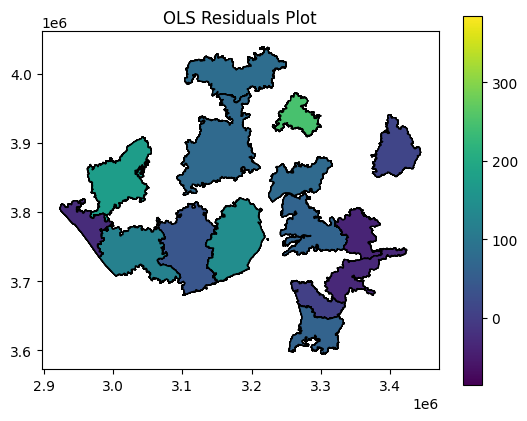

In [21]:
import matplotlib.pyplot as plt
gujarat_gdf['residuals'] = ols.u
gujarat_gdf.plot(column='residuals', legend=True, cmap='viridis', edgecolor='black')
plt.title('OLS Residuals Plot')
plt.show()

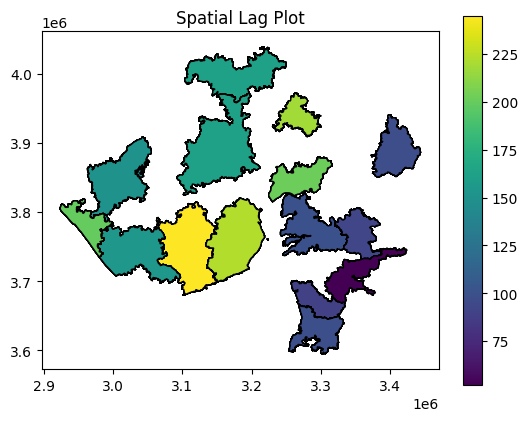

In [22]:
from libpysal.weights import lag_spatial
gujarat_gdf['lag_CRIME_RATE_PER_100K'] = lag_spatial(weight, gujarat_gdf['CRIME_RATE_PER_100K'])
gujarat_gdf.plot(column='lag_CRIME_RATE_PER_100K', legend=True, cmap='viridis', edgecolor='black')
plt.title('Spatial Lag Plot')
plt.show()

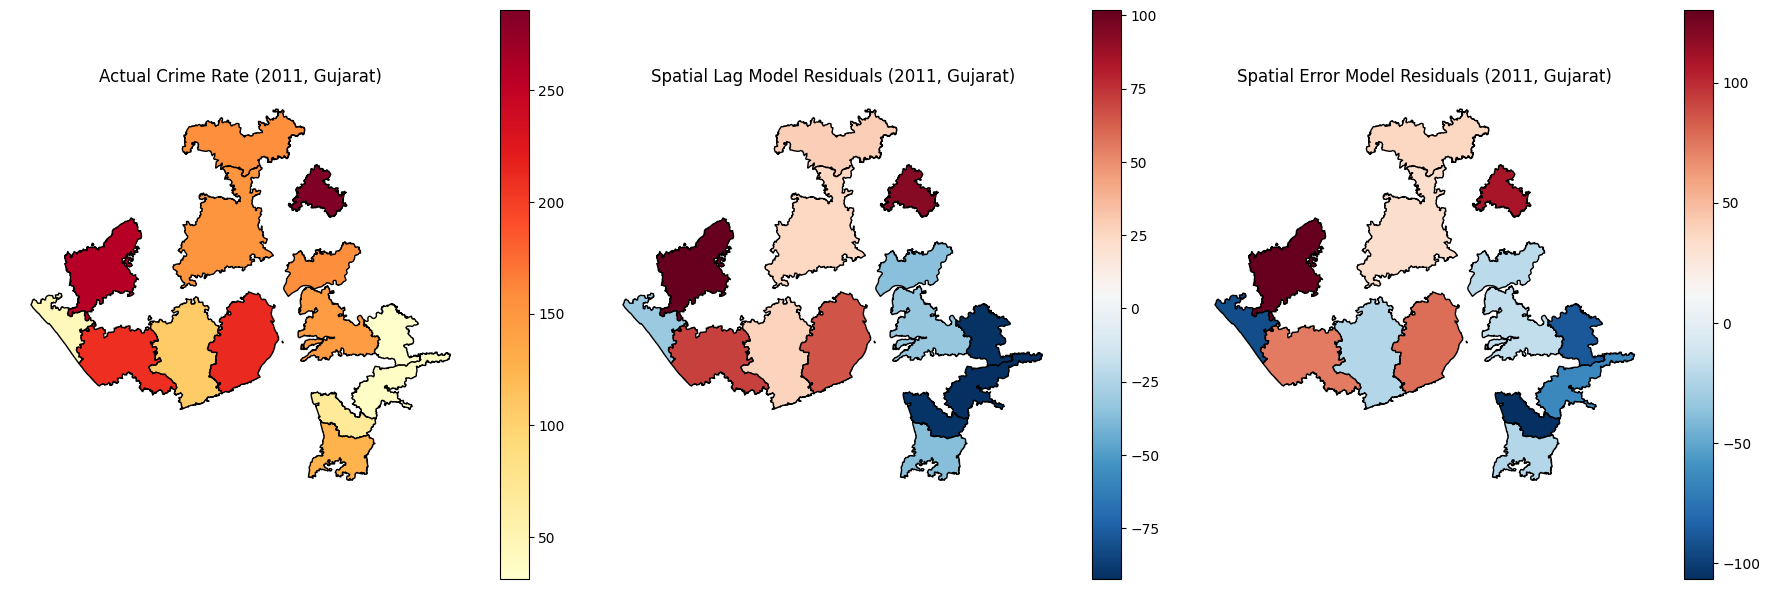

In [41]:
import matplotlib.pyplot as plt

# Add residuals to the merged_data_2011 GeoDataFrame
merged_data_2011['lag_2011_residuals'] = lag_2011.u
merged_data_2011['error_2011_residuals'] = error_2011.u

fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot Actual Crime Rate for 2011
merged_data_2011.plot(column='CRIME_RATE_PER_100K', ax=axs[0], edgecolor='black', legend=True, cmap='YlOrRd')
axs[0].set_title("Actual Crime Rate (2011, Gujarat)")
axs[0].set_axis_off()

# Plot Spatial Lag Model Residuals for 2011
merged_data_2011.plot(column='lag_2011_residuals', ax=axs[1], edgecolor='black', legend=True, cmap='RdBu_r')
axs[1].set_title("Spatial Lag Model Residuals (2011, Gujarat)")
axs[1].set_axis_off()

# Plot Spatial Error Model Residuals for 2011
merged_data_2011.plot(column='error_2011_residuals', ax=axs[2], edgecolor='black', legend=True, cmap='RdBu_r')
axs[2].set_title("Spatial Error Model Residuals (2011, Gujarat)")
axs[2].set_axis_off()

plt.tight_layout()
plt.show()

### Interpretation of 2011 Spatial Model Visualizations

*   **Actual Crime Rate:** Displays the geographic distribution of crime rates across Gujarat districts in 2011.
*   **Spatial Lag Model Residuals:** Shows that some spatial clustering in the residuals remains (Moran's I = 0.487), indicating the model didn't fully capture all spatial dependencies.
*   **Spatial Error Model Residuals:** Exhibits a more random pattern (Moran's I = -0.114, non-significant), suggesting this model more effectively accounts for spatial autocorrelation in the error term for 2011.

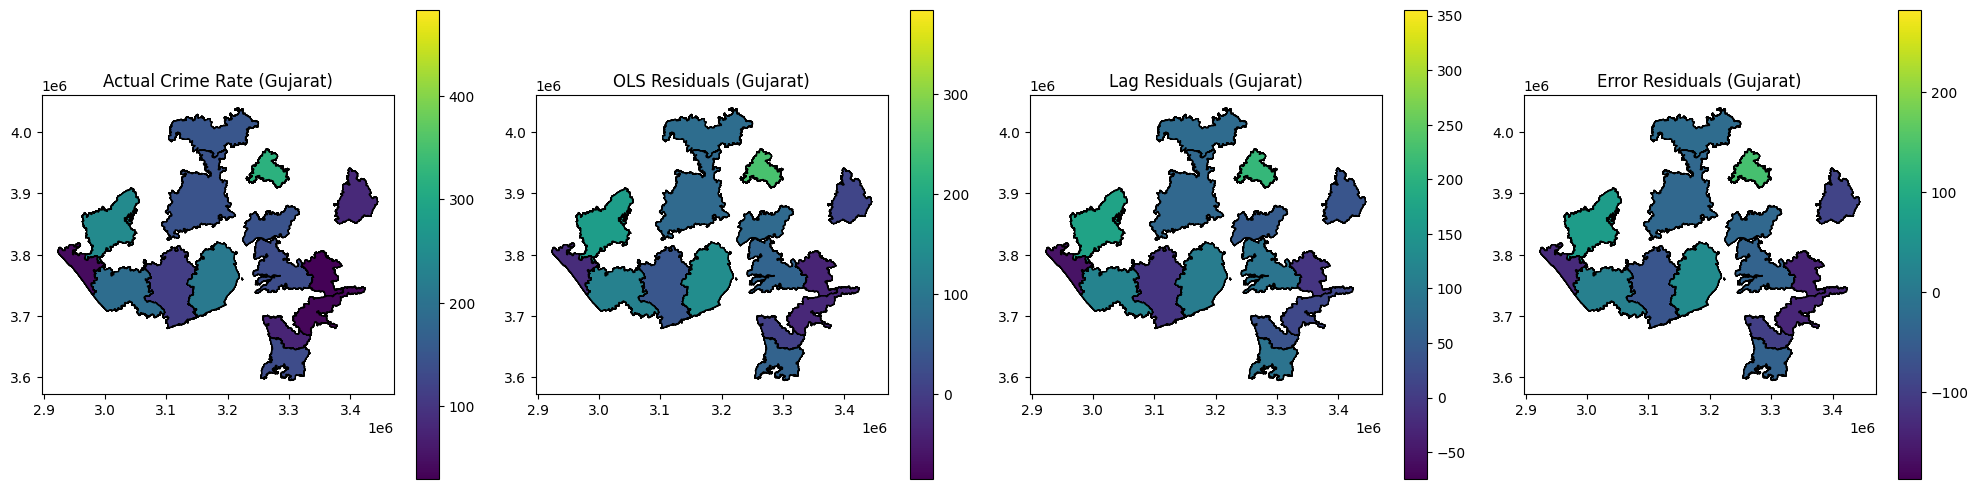

In [23]:
gujarat_gdf['residuals'] = ols.u
gujarat_gdf['lag_residuals'] = lag.u
gujarat_gdf['error_residuals'] = error.u

fig, axs = plt.subplots(1, 4, figsize=(20, 5))

gujarat_gdf.plot(column='CRIME_RATE_PER_100K', ax=axs[0], edgecolor='black', legend=True)
axs[0].set_title("Actual Crime Rate (Gujarat)")

gujarat_gdf.plot(column='residuals', ax=axs[1], edgecolor='black', legend=True)
axs[1].set_title("OLS Residuals (Gujarat)")

gujarat_gdf.plot(column='lag_residuals', ax=axs[2], edgecolor='black', legend=True)
axs[2].set_title("Lag Residuals (Gujarat)")

gujarat_gdf.plot(column='error_residuals', ax=axs[3], edgecolor='black', legend=True)
axs[3].set_title("Error Residuals (Gujarat)")

plt.tight_layout()
plt.show()

### **Overall Project Summary: Spatial Analysis of Crime in GUJARAT**

This project conducted a spatial analysis of crime patterns across districts in **Gujarat**, integrating crime and literacy data to understand distribution, temporal trends, and spatial influences.

**Key Findings:**

1.  **Data Preparation:** Crime statistics (2001-2012) and Literacy Data (2011) were merged with district boundary shapefiles. District names were standardized, and hypothetical population data was generated to calculate **crime rates per 100,000 people**.

2.  **Exploratory Spatial Data Analysis (ESDA):**
    *   **Global Moran's I** confirmed significant positive spatial autocorrelation in crime rates (0.268, p=0.001), indicating spatial clustering.
    *   **LISA** identified specific 'High-High' crime hotspots, including AMRELI, ANAND, BHAVNAGAR, GANDHINAGAR, PATAN, and SURENDRANAGAR.

3.  **OLS Regression:**
    *   **District-wise OLS** showed varied crime trends across districts.
    *   An **overall OLS model** for Gujarat performed poorly (negative R²) and exhibited high spatial autocorrelation in its residuals (Moran's I: 0.265, p=0.001), demonstrating its inadequacy for spatially dependent data.

4.  **Spatial Regression Models (Overall Gujarat):**
    *   The **Spatial Lag Model (ML_Lag)** revealed a significant spatial lag coefficient (ρ = 0.521, p=0.00003), indicating strong influence of neighboring districts' crime rates. Its residuals showed minimal spatial autocorrelation (-0.063, p=0.001).
    *   The **Spatial Error Model (ML_Error)** was less effective, with a non-significant lambda and moderate spatial autocorrelation remaining in its residuals (0.266, p=0.001).

5.  **Spatial Models with Literacy Data (2011 Specific):**
    *   For 2011 data, neither 'Literacy' nor the spatial terms were consistently statistically significant in either the **Spatial Lag** or **Spatial Error** models.
    *   The 2011 Spatial Lag Model residuals still showed significant spatial autocorrelation (0.487, p=0.039), while the 2011 Spatial Error Model residuals showed no significant spatial autocorrelation (-0.114, p=0.468), indicating it handled error structure more effectively in this specific context.
